In [1]:
# Define source path for journal results
SOURCE_PATH = "../../save_and_results/old/journal/"

In [4]:
import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from utils.display_tools import load_best_forecasts
import matplotlib

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
lot = pickle.load(open("../../save_and_results/cache_lot.p", "rb"))
data = pickle.load(open("../../save_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../../save_and_results/cache_exogs.p", "rb"))

In [7]:
d = data["Moehne"]["desc1"]
y_ = d.loc[d.index.year == 2020]

In [8]:
chronos = pd.read_csv(
    SOURCE_PATH + "chronos/Moehne_desc1_chronos_zero_shot_chronos.csv", index_col=0)
tfm = pd.read_csv(
    SOURCE_PATH + "/tfm/Moehne_desc1_tfm_zero_shot_chronos.csv", index_col=0)

model_spec, forecasts = load_best_forecasts(
        SOURCE_PATH + "0", direction="desc1"
    )

model_spec2, forecasts2 = load_best_forecasts(
        SOURCE_PATH + "1", direction="desc1"
    )

In [9]:
score = pd.DataFrame([np.abs(forecasts[x] - y_.values).mean() for x in forecasts.keys()], index = forecasts.keys())
score2 = pd.DataFrame([np.abs(forecasts2[x] - y_.values).mean() for x in forecasts2.keys()], index = forecasts2.keys())

In [10]:
score.loc["chronos"] = np.abs(y_ - chronos.values[:-1]).mean()
score.loc["tfm"] = np.abs(y_ - tfm.values[:-1]).mean()

In [11]:
a = score2.loc[["linear"]].min(axis=0)
b = score.loc[["sarimax", "linear", "var"]].min(axis=0)
c = score.loc[["ada", "forest"]].min(axis=0)
d = score.loc[["tfm", "chronos"]].min(axis=0)
comp = pd.concat([a,b,c,d],axis=1)

In [12]:
cmap = matplotlib.colormaps['viridis']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1,5))

10905
10961
10982
11038
11161
11176
11208
11243


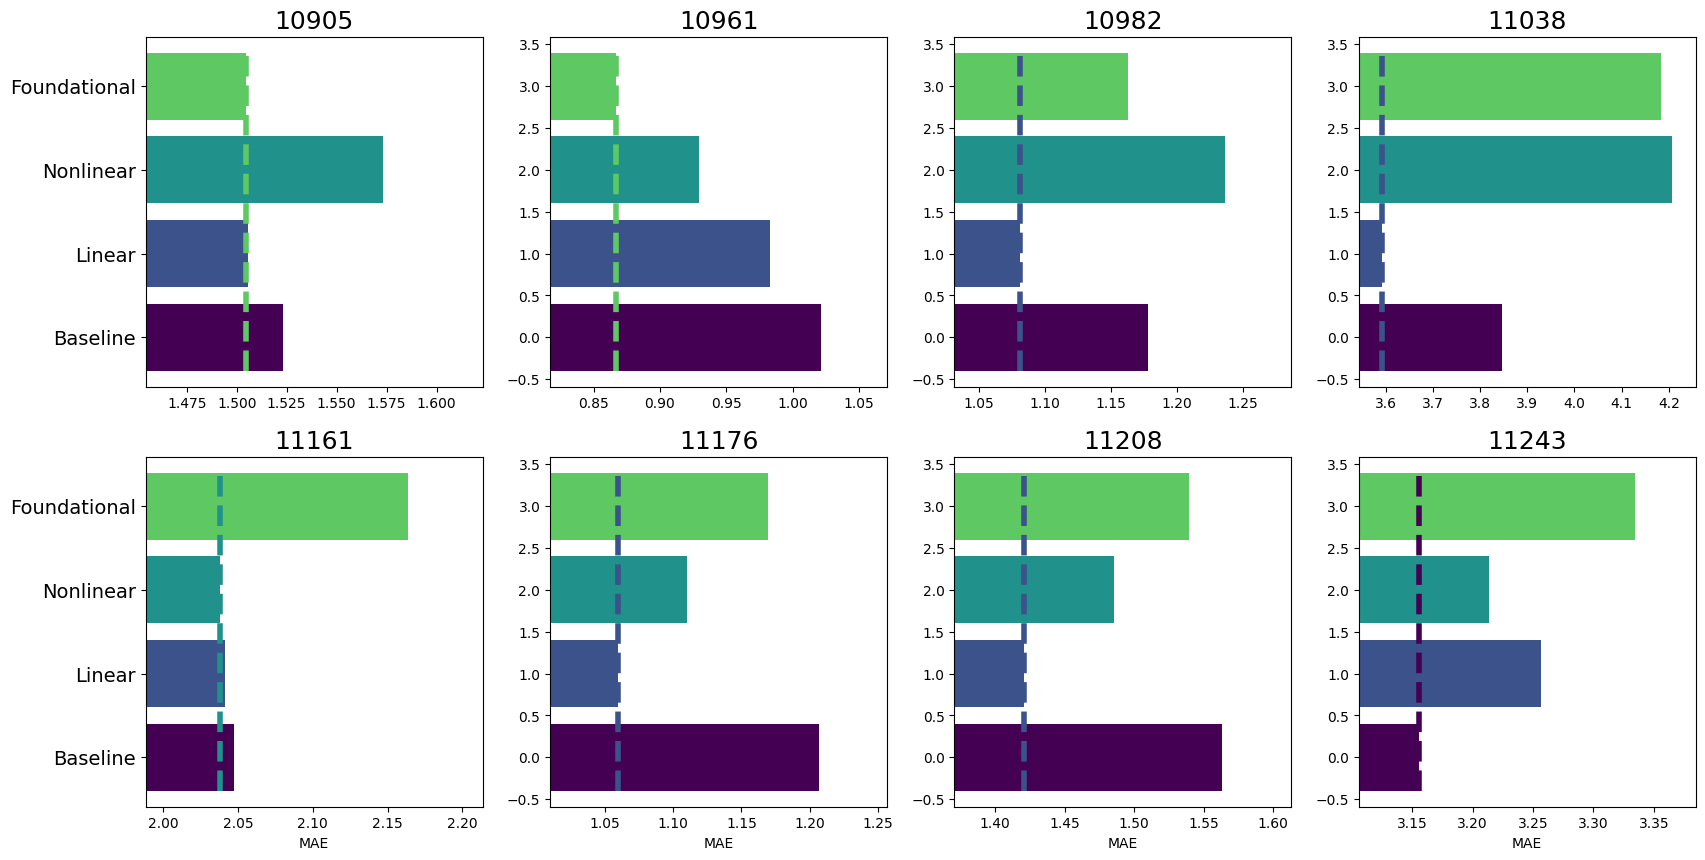

In [13]:
labs = ["Baseline", "Linear", "Nonlinear", "Foundational"]

fig, ax = plt.subplots(2,4,figsize=(20, 10))

for x in range(4):
    ax[1,x].set_xlabel("MAE")


count = 0
for index, row in comp.iterrows():
    print(index)
    ax[int(count > 3), count%4].barh(np.arange(0,4), row.values,color = colors[:4])
    ax[int(count > 3), count%4].set_title(index, fontsize=18)
    ax[int(count > 3), count%4].set_xlim([row.values.min()-0.05,row.values.max() + 0.05])
    ax[int(count> 3), count%4].grid(False)
    ax[int(count> 3), count%4].vlines(row.values.min(),-0.4,3.4, linestyle="dashed", color=colors[row.values.argmin()], linewidth=4)
    count+=1

ax[1,0].set_yticks(np.arange(4), labels=labs, fontsize=14) 
ax[0,0].set_yticks(np.arange(4), labels=labs, fontsize=14) 





plt.show()